In [2]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path


In [3]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [4]:
def generate_chinrest_dataframe(df, i):
    df_chin = df[~df["view_dist_mm"].isna()][["view_dist_mm", "trial_index", "rt"]]
    df_chin["experiment"] = i
    return df_chin

In [5]:
files = Path("./data/all-exp-separados/").glob("*.csv")
i = 0
for file in files:
    if "distance" in str(file):
        if "10" in str(file):
          df = pd.read_csv(file)
          df_chin = df[~df["view_dist_mm"].isna()][["view_dist_mm", "trial_index"]]
          df_chin["experiment"] = i

df_chin.head()

,view_dist_mm,trial_index,experiment
3,491.69,3,0
4,468.84,4,0
5,469.73,5,0


In [6]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
dfs_chin = []
i = 0
for file in files:
    if "distance" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        dfs.append(df_tmp)
        df_virtual_chin_tmp = generate_chinrest_dataframe(df, i)
        dfs_chin.append(df_virtual_chin_tmp)
        print(df_virtual_chin_tmp)
        i+=1

df_webgazer = pd.concat(dfs)
df_virtual_chin = pd.concat(dfs_chin)
print(len(df_webgazer))

data/distance-experiment-11 (1).csv
3923
   view_dist_mm  trial_index       rt  experiment
3        557.20            3  79933.0           0
4        532.64            4  41851.0           0
5        536.57            5  38358.0           0
data/distance-experiment-10 (1).csv
5986
   view_dist_mm  trial_index        rt  experiment
3        491.69            3  142251.0           1
4        468.84            4   46133.0           1
5        469.73            5   40362.0           1
data/distance-experiment-12 (1).csv
5290
   view_dist_mm  trial_index        rt  experiment
3        399.33            3  101826.0           2
4        355.96            4   64594.0           2
5        588.19            5   37516.0           2
data/distance-experiment-7.csv
6891
   view_dist_mm  trial_index        rt  experiment
3        629.34            3  147251.0           3
4        636.82            4   41477.0           3
5        622.95            5   49609.0           3
data/distance-experiment-6.cs

In [26]:
df_virtual_chin.head()

,view_dist_mm,trial_index,rt,experiment
3,557.20,3,79933.0,0
4,532.64,4,41851.0,0
5,536.57,5,38358.0,0
3,491.69,3,142251.0,1
4,468.84,4,46133.0,1


In [29]:
df_virtual_chin.groupby("experiment").mean()

,view_dist_mm,trial_index,rt
experiment,,,
0,542.136667,4.0,53380.666667
1,476.753333,4.0,76248.666667
2,447.826667,4.0,67978.666667
3,629.703333,4.0,79445.666667
4,671.273333,4.0,98862.000000
5,638.166667,4.0,55242.666667
6,579.063333,4.0,29207.000000
7,482.676667,4.0,51769.333333
8,629.063333,4.0,104679.333333


In [ ]:
df_webgazer["error"] = df_webgazer.apply(
    lambda row: blinkColors.isBlinkByColors(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)

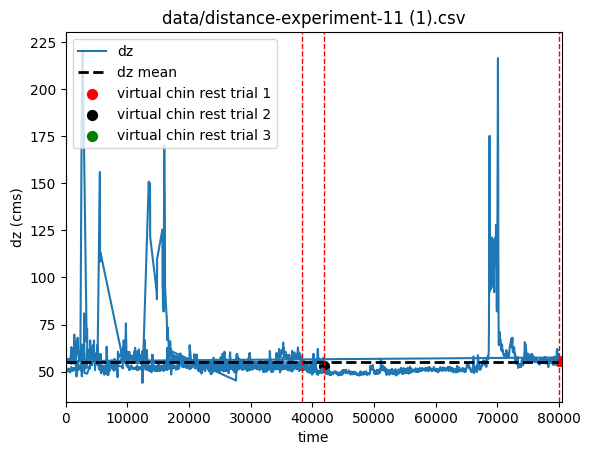

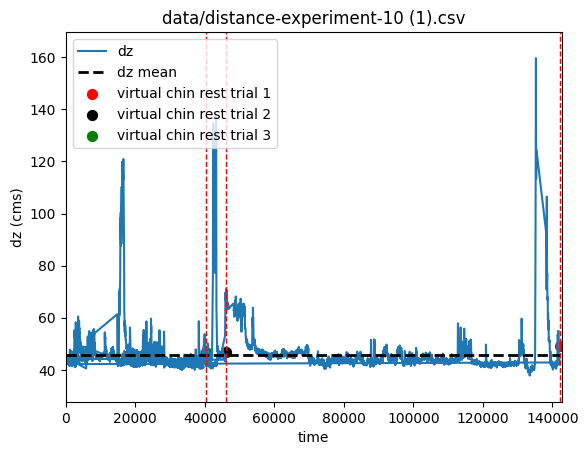

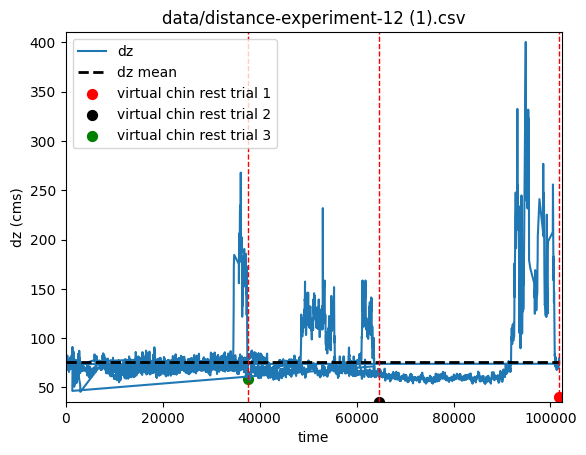

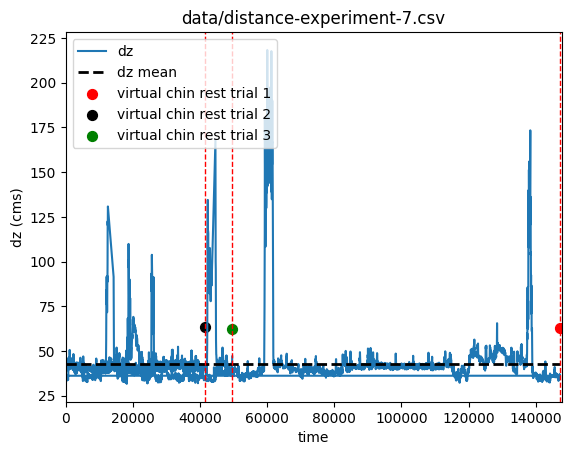

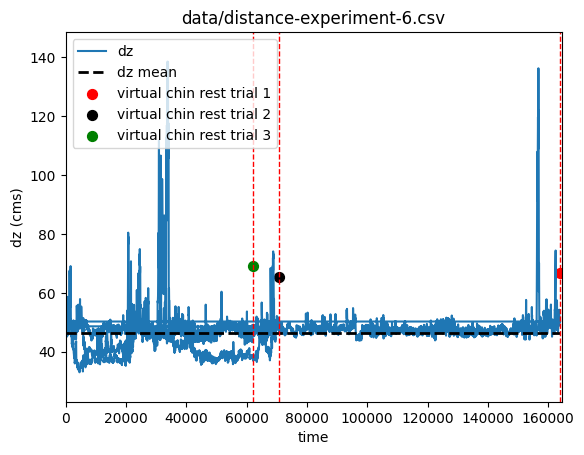

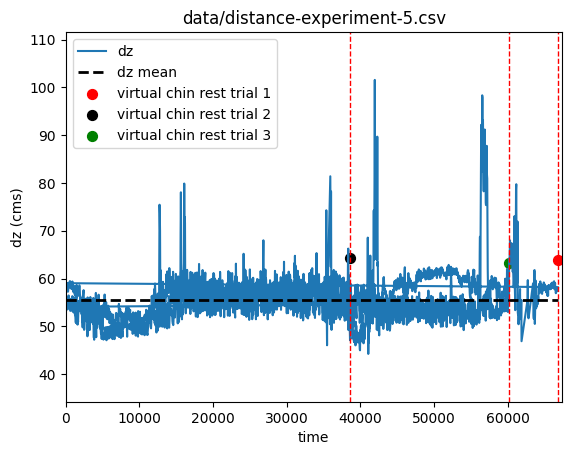

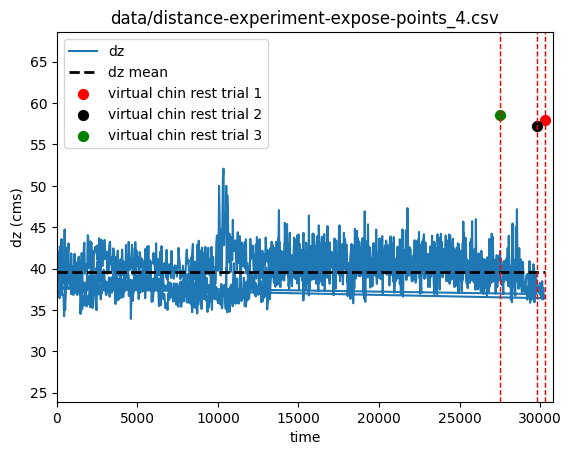

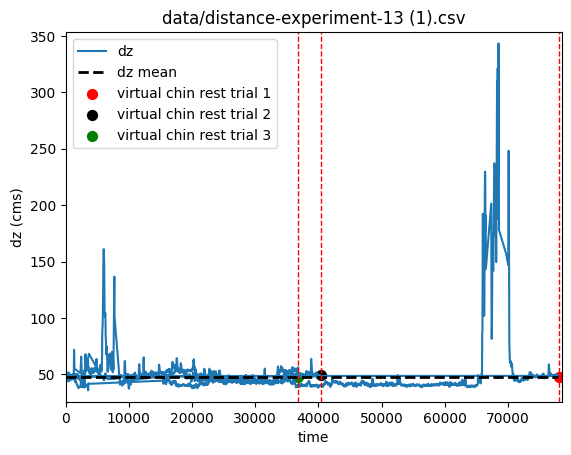

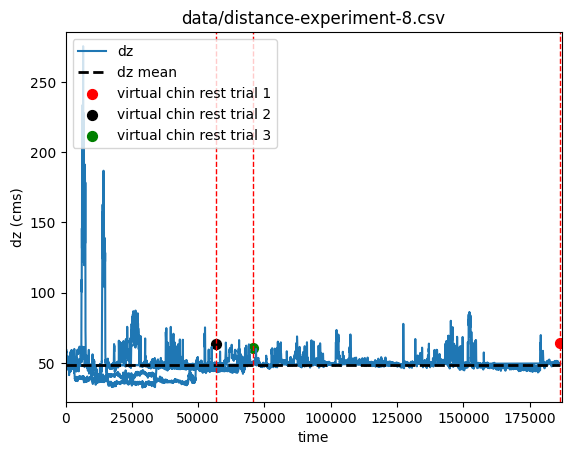

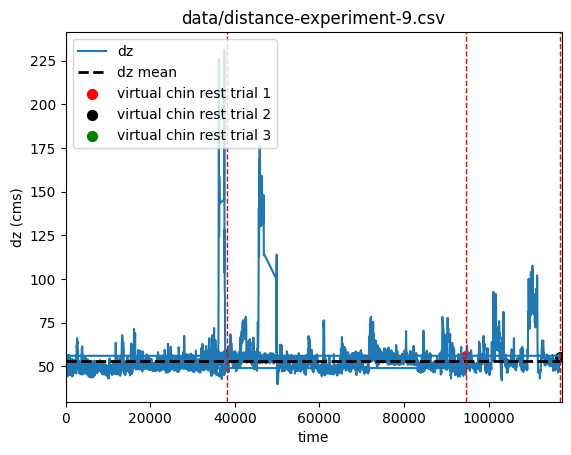

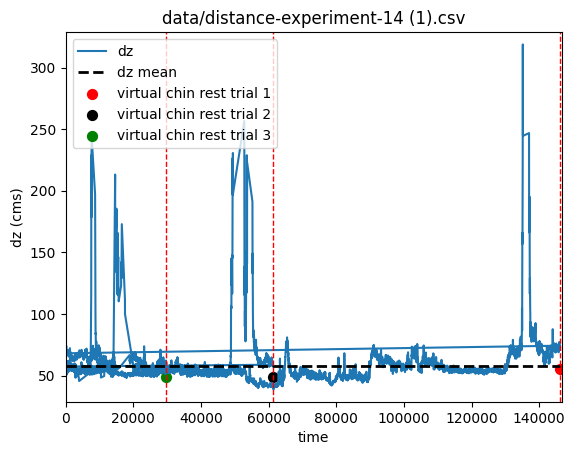

In [5]:
files = Path("./data").glob("*.csv")

for file in files:
    if "distance" in str(file):
        df = pd.read_csv(file)
        df_webgazer = generate_webgazer_dataframe(df)

        df_virtual_chin = df[~df["view_dist_mm"].isna()]
        df_virtual_chin.loc[:, ["view_dist_centimeters"]] = (
            df[~df["view_dist_mm"].isna()]["view_dist_mm"] / 10
        )
        (
            df_virtual_chin["rt"].reset_index(drop=True),
            df_webgazer.groupby("trial")["t"].max(),
        )

        df_webgazer = df_webgazer.astype({"dz": float, "t": float})
        df_webgazer.plot(x="t", y="dz")
        plt.xlabel("time")
        plt.ylabel("dz (cms)")
        plt.xlim(0, df_webgazer["t"].max() + 500)
        plt.hlines(
            df_webgazer["dz"].mean(),
            df_webgazer["t"].min(),
            df_webgazer["t"].max(),
            color="k",
            linestyle="--",
            lw=2,
            label="dz mean",
        )
        colors = ["r", "k", "g"]
        for i, (virtual_chin_time, virtual_chin_distance) in enumerate(
            zip(df_virtual_chin["rt"], df_virtual_chin["view_dist_centimeters"])
        ):
            plt.axvline(virtual_chin_time, color="red", linestyle="--", lw=1)
            plt.scatter(
                virtual_chin_time,
                virtual_chin_distance,
                s=50,
                color=colors[i],
                label=f"virtual chin rest trial {i + 1}",
            )
            plt.ylim(
                min(df_webgazer["dz"].min(), virtual_chin_distance) - 10,
                max(virtual_chin_distance, df_webgazer["dz"].max()) + 10,
            )

        plt.title(file)
        plt.legend(loc="upper left")
        plt.show()


In [12]:
df_virtual_chin.head()

,load_time,trial_type,trial_index,time_elapsed,internal_node_id,jspsych_start_time,success,item_width_mm,item_height_mm,item_width_px,...,view_dist_mm,rt,item_width_deg,px2deg,win_width_deg,win_height_deg,webgazer_data,webgazer_targets,events,view_dist_centimeters
3,NaN,virtual-chinrest,3,127204,0.0-3.0,NaN,NaN,85.6,53.98,422.0,...,557.20,79933.0,8.784829,48.037359,29.976669,18.735418,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,55.720
4,NaN,virtual-chinrest,4,169054,0.0-4.0,NaN,NaN,85.6,53.98,422.0,...,532.64,41851.0,9.188201,45.928467,31.353104,19.595690,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,53.264
5,NaN,virtual-chinrest,5,207412,0.0-5.0,NaN,NaN,85.6,53.98,419.0,...,536.57,38358.0,9.121189,45.936993,31.347285,19.592053,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,53.657
3,NaN,virtual-chinrest,3,311704,0.0-3.0,NaN,NaN,85.6,53.98,408.0,...,491.69,142251.0,9.949739,41.006099,35.116727,21.947954,"[{""x"":0,""y"":0,""t"":5,""importantKeypoints"":{""nos...",{},NaN,49.169
4,NaN,virtual-chinrest,4,357837,0.0-4.0,NaN,NaN,85.6,53.98,416.0,...,468.84,46133.0,10.432050,39.877111,36.110941,22.569338,"[{""x"":0,""y"":0,""t"":4,""importantKeypoints"":{""nos...",{},NaN,46.884
